In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
dataset=pd.read_csv('bank-full.csv')

In [3]:
dataset.head()

,Age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [5]:
dataset.describe()

,Age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [6]:
dataset.shape

(45211, 17)

In [7]:
dataset=dataset.drop_duplicates()

In [8]:
dataset.isnull().sum()

Age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [9]:
dataset.select_dtypes("object")

,job,marital,education,default,housing,loan,contact,month,poutcome,y
0,management,married,tertiary,no,yes,no,unknown,may,unknown,no
1,technician,single,secondary,no,yes,no,unknown,may,unknown,no
2,entrepreneur,married,secondary,no,yes,yes,unknown,may,unknown,no
3,blue-collar,married,unknown,no,yes,no,unknown,may,unknown,no
4,unknown,single,unknown,no,no,no,unknown,may,unknown,no
...,...,...,...,...,...,...,...,...,...,...
45206,technician,married,tertiary,no,no,no,cellular,nov,unknown,yes
45207,retired,divorced,primary,no,no,no,cellular,nov,unknown,yes
45208,retired,married,secondary,no,no,no,cellular,nov,success,yes
45209,blue-collar,married,secondary,no,no,no,telephone,nov,unknown,no


In [10]:
dataset['pdays']=dataset['pdays'].abs()

### Data Visualizatiion

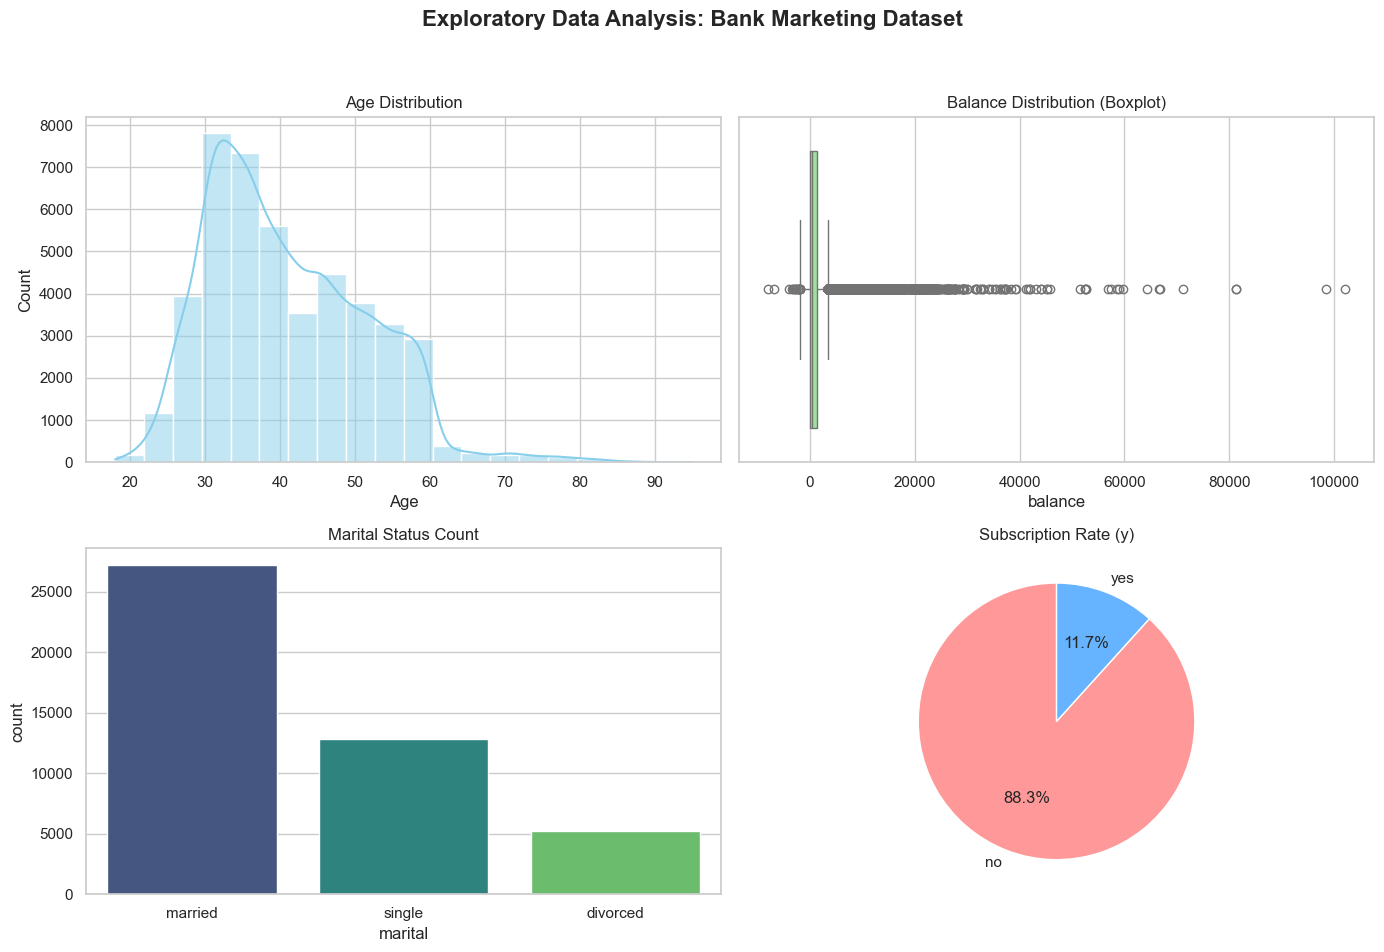

In [11]:
# Setting the visual style
sns.set_theme(style="whitegrid")

# Initialize the 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Exploratory Data Analysis: Bank Marketing Dataset', fontsize=16, fontweight='bold')

# 1. Distribution of Age (Quantitative)
sns.histplot(dataset['Age'], bins=20, kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Age Distribution')

# 2. Distribution of Balance (Quantitative - Outlier Check)
sns.boxplot(x=dataset['balance'], ax=axes[0, 1], color='lightgreen')
axes[0, 1].set_title('Balance Distribution (Boxplot)')

# 3. Marital Status Count (Categorical)
sns.countplot(x='marital', data=dataset, ax=axes[1, 0], palette='viridis', hue='marital', legend=False)
axes[1, 0].set_title('Marital Status Count')

# 4. Target Variable Success Rate (Categorical)
dataset['y'].value_counts().plot.pie(ax=axes[1, 1], autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
axes[1, 1].set_title('Subscription Rate (y)')
axes[1, 1].set_ylabel('')

# Clean up layout
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

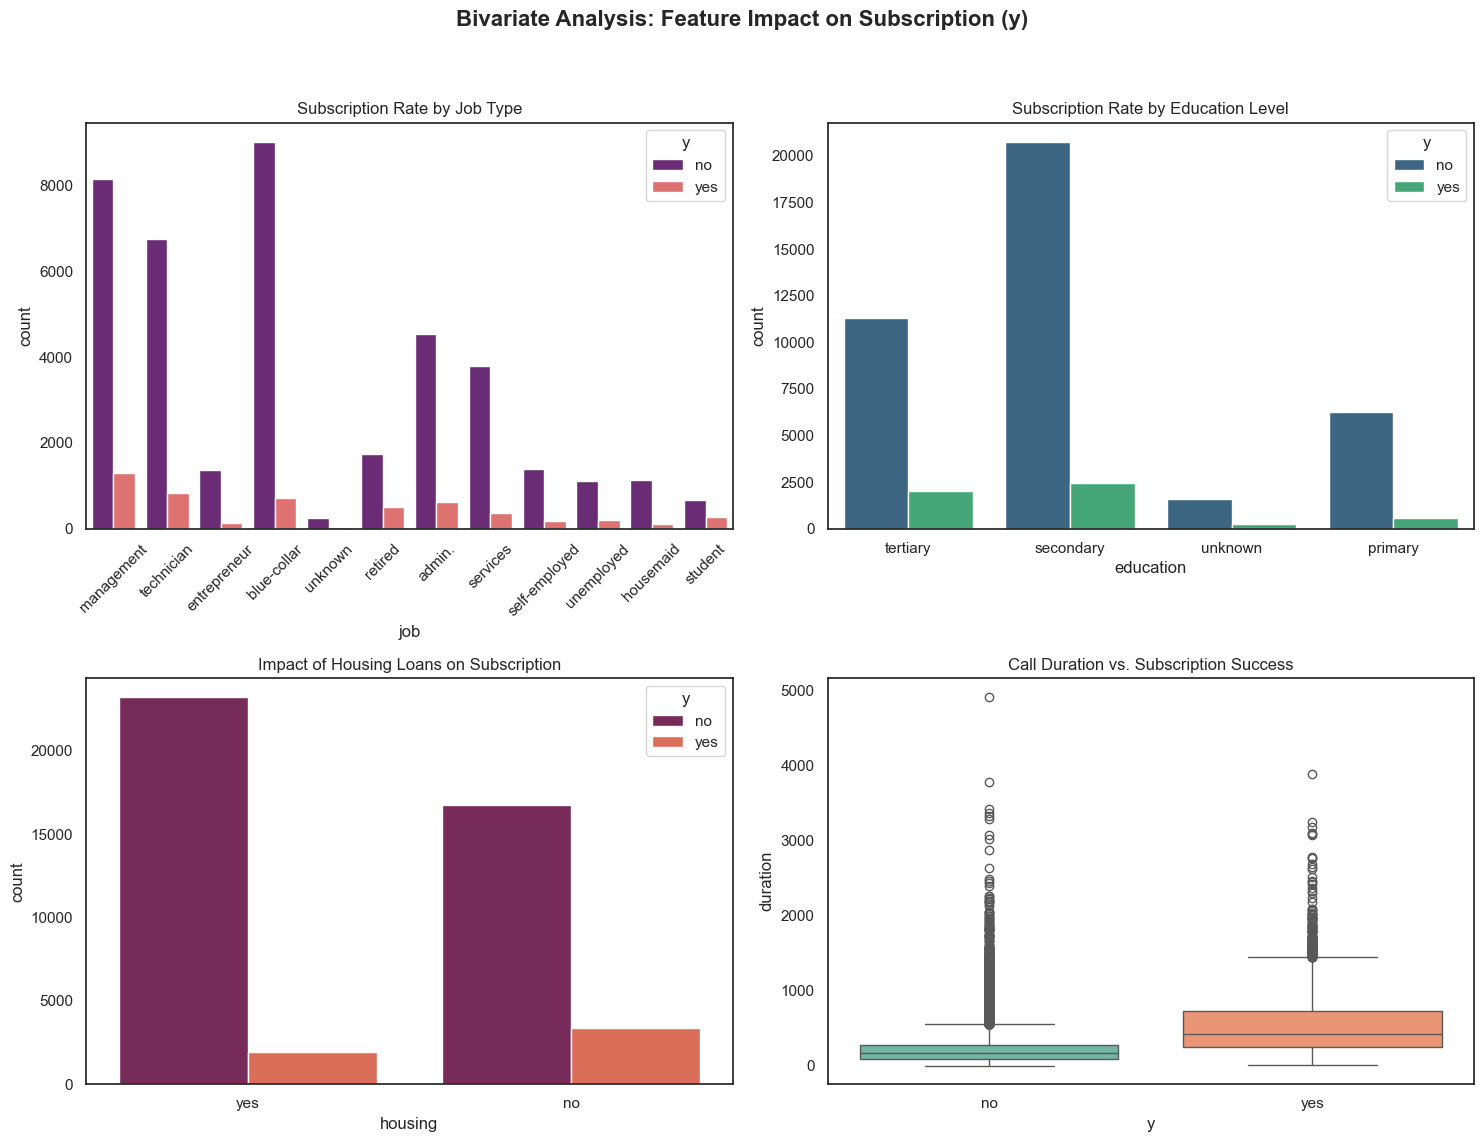

In [12]:
sns.set_theme(style="white")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Bivariate Analysis: Feature Impact on Subscription (y)', fontsize=16, fontweight='bold')

# 1. Job vs Subscription - Identifying which sectors actually convert
sns.countplot(x='job', hue='y', data=dataset, ax=axes[0, 0], palette='magma')
axes[0, 0].set_title('Subscription Rate by Job Type')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Education vs Subscription - Does academic background influence the result?
sns.countplot(x='education', hue='y', data=dataset, ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title('Subscription Rate by Education Level')

# 3. Housing Loan vs Subscription - Debt is a massive factor in financial behavior
sns.countplot(x='housing', hue='y', data=dataset, ax=axes[1, 0], palette='rocket')
axes[1, 0].set_title('Impact of Housing Loans on Subscription')

# 4. Duration vs Subscription - The most influential (and often leaky) feature
# Using a boxplot to see the distribution of call duration for 'yes' vs 'no'
sns.boxplot(x='y', y='duration', data=dataset, ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Call Duration vs. Subscription Success')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

###  Encode all categorical features properly In pipeline

In [44]:
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler , OneHotEncoder ,LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier , AdaBoostClassifier , GradientBoostingClassifier
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix ,precision_recall_curve
from sklearn.model_selection import RandomizedSearchCV
from imblearn.combine import SMOTETomek

In [65]:
categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
numerical_cols = ['Age', 'balance', 'day', 'campaign', 'pdays', 'previous']

In [66]:
la=LabelEncoder()
dataset['y']=la.fit_transform(dataset['y'])

In [67]:
input_data=dataset.drop('y', axis=1)
output=dataset['y']

In [68]:
X_train, X_test, y_train, y_test = train_test_split(input_data, output, test_size=0.2, random_state=42)

In [69]:
# Preprocessing for numerical data: 
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Preprocessing for categorical data:
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [70]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='passthrough' # Or 'drop' if you want to discard unspecified columns
)

### Create Models Using Pipelines

In [71]:
dataset['y'].value_counts()

y
0    39922
1     5289
Name: count, dtype: int64

In [72]:
models = {
    "Logistic_Regression": LogisticRegression(max_iter=1000, random_state=42 , class_weight="balanced"),
    "Random_Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42),
    "Gradient_Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
}

# Create a container for the pipelines
pipelines = {}

for name, model in models.items():
    pipelines[name] = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTETomek(random_state=42)),
        ('classifier', model)
    ])



### Logistic Regression Model

In [73]:
lr_pipeline = pipelines["Logistic_Regression"]

In [82]:
lr_pipeline.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [83]:
lr_pred=lr_pipeline.predict(X_test)

In [84]:
accuracy_score(y_test,lr_pred)*100

84.58476169412805

In [77]:
print("Classification Report",classification_report(y_test,lr_pred))

Classification Report               precision    recall  f1-score   support

           0       0.97      0.85      0.91      7952
           1       0.43      0.82      0.56      1091

    accuracy                           0.85      9043
   macro avg       0.70      0.83      0.73      9043
weighted avg       0.91      0.85      0.86      9043



### Random Forest Classifier

In [27]:
Rfc_pipeline = pipelines["Random_Forest"]

In [28]:
Rfc_pipeline.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [29]:
Rfc_pred=Rfc_pipeline.predict(X_test)

In [30]:
accuracy_score(y_test, Rfc_pred)*100

89.73791883224594

In [31]:
print("Classification Report",classification_report(y_test,Rfc_pred))

Classification Report               precision    recall  f1-score   support

           0       0.94      0.94      0.94      7952
           1       0.58      0.57      0.57      1091

    accuracy                           0.90      9043
   macro avg       0.76      0.76      0.76      9043
weighted avg       0.90      0.90      0.90      9043



### Ada Boosting Classifier

In [32]:
Ada_pipeline=pipelines['AdaBoost']

In [33]:
Ada_pipeline.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [34]:
Ada_pred=Ada_pipeline.predict(X_test)

In [35]:
print("Classification Report",classification_report(y_test,Ada_pred))

Classification Report               precision    recall  f1-score   support

           0       0.96      0.90      0.93      7952
           1       0.48      0.70      0.57      1091

    accuracy                           0.87      9043
   macro avg       0.72      0.80      0.75      9043
weighted avg       0.90      0.87      0.88      9043



### Gradient Boosting Classifier

In [36]:
Gb_pipeline=pipelines['Gradient_Boosting']

In [37]:
Gb_pipeline.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [38]:
Gb_pred=Gb_pipeline.predict(X_test)

In [39]:
print("Classification Report",classification_report(y_test,Gb_pred))

Classification Report               precision    recall  f1-score   support

           0       0.96      0.90      0.93      7952
           1       0.50      0.75      0.60      1091

    accuracy                           0.88      9043
   macro avg       0.73      0.82      0.76      9043
weighted avg       0.91      0.88      0.89      9043



* All our models are not performing well on miniorites class . We choose threshold value on Gradient Boosting because it performing a well  as compare to others.

In [54]:
y_scores = pipelines["Gradient_Boosting"].predict_proba(X_test)[:, 1]

# Get precision and recall values for different thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)

# Find the threshold that gives us at least 80% Precision
target_precision = 0.40
idx = np.where(precisions >= target_precision)[0][0]
optimal_threshold = thresholds[idx]

print(f"To achieve {target_precision*100}% Efficiency, set threshold to: {optimal_threshold:.4f}")

# Apply the new threshold
y_pred_efficient = (y_scores >= optimal_threshold).astype(int)

To achieve 40.0% Efficiency, set threshold to: 0.3179


In [55]:
print("Classification Report",classification_report(y_test,y_pred_efficient))

Classification Report               precision    recall  f1-score   support

           0       0.98      0.82      0.89      7952
           1       0.40      0.88      0.55      1091

    accuracy                           0.83      9043
   macro avg       0.69      0.85      0.72      9043
weighted avg       0.91      0.83      0.85      9043



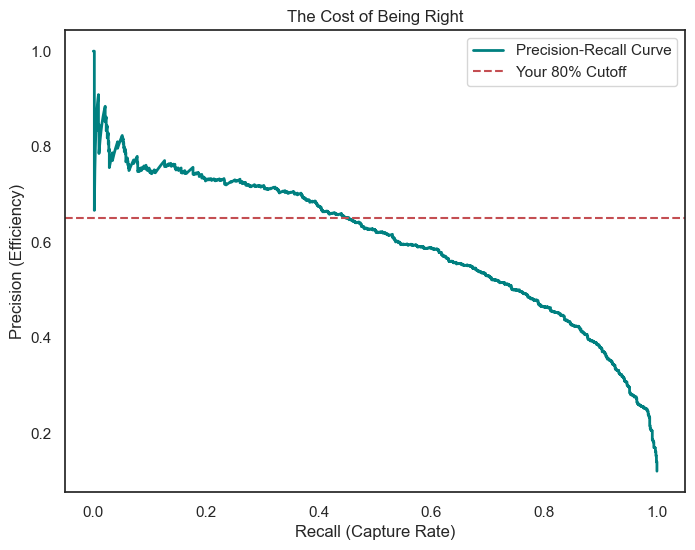

In [58]:
plt.figure(figsize=(8, 6))
plt.plot(recalls, precisions, label='Precision-Recall Curve', color='teal', lw=2)
plt.axhline(y=0.65, color='r', linestyle='--', label='Your 80% Cutoff')
plt.xlabel('Recall (Capture Rate)')
plt.ylabel('Precision (Efficiency)')
plt.title('The Cost of Being Right')
plt.legend()
plt.show()

In [96]:
# 1. Age Binning (Life Stages)
dataset['life_stage'] = pd.cut(dataset['Age'], bins=[0, 25, 45, 65, 100], labels=['Student', 'Adult', 'Mid-Age', 'Senior'])
    
    # 2. Financial Metrics
dataset['is_in_debt'] = (dataset['balance'] < 0).astype(int)
dataset['balance_scaled'] = np.log1p(dataset['balance'].clip(lower=0)) # Basic log transform for positive balance
    
    # 3. Cyclical Day Encoding
dataset['day_sin'] = np.sin(2 * np.pi * dataset['day'] / 31)
dataset['day_cos'] = np.cos(2 * np.pi * dataset['day'] / 31)
    
    # 4. Campaign Behavioral Features
dataset['total_interactions'] = dataset['campaign'] + dataset['previous']
dataset['has_been_contacted_before'] = (dataset['pdays'] != -1).astype(int)

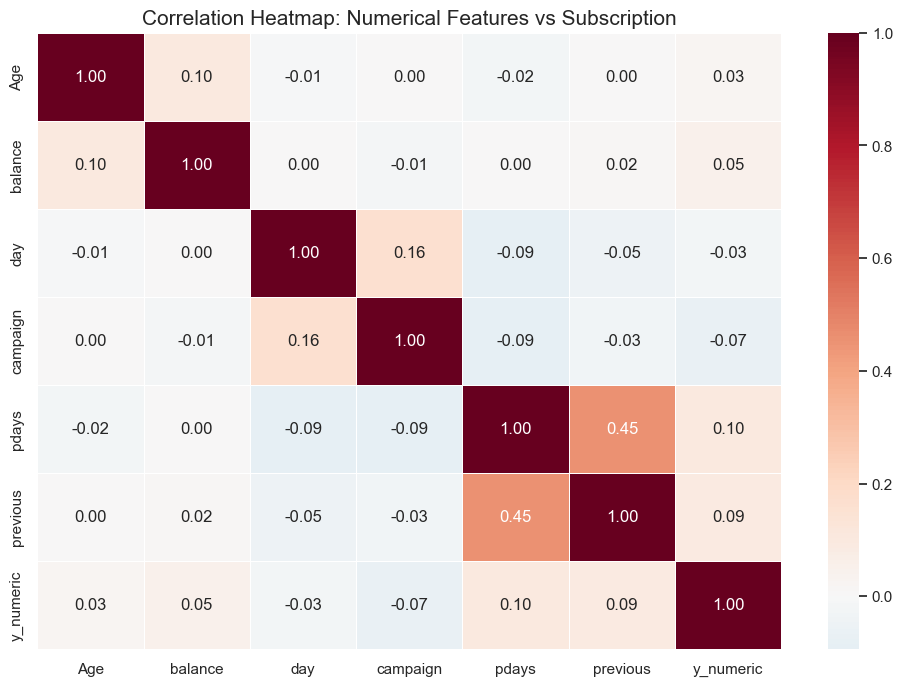

In [98]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure the target 'y' is numeric for the correlation matrix
if dataset['y'].dtype == 'object':
    dataset['y_numeric'] = dataset['y'].map({'yes': 1, 'no': 0})
else:
    dataset['y_numeric'] = dataset['y']

# Define the features provided
numerical_cols = ['Age', 'balance', 'day', 'campaign', 'pdays', 'previous', 'y_numeric']

# Calculate the correlation matrix
corr_matrix = dataset[numerical_cols].corr()

# Plotting the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f", linewidths=0.5)

plt.title('Correlation Heatmap: Numerical Features vs Subscription', fontsize=15)
plt.show()

In [97]:
dataset.head()

,Age,job,marital,education,default,balance,housing,loan,contact,day,...,previous,poutcome,y,life_stage,is_in_debt,balance_scaled,day_sin,day_cos,total_interactions,has_been_contacted_before
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,...,0,unknown,0,Mid-Age,0,7.670429,0.848644,0.528964,1,1
1,44,technician,single,secondary,no,29,yes,no,unknown,5,...,0,unknown,0,Adult,0,3.401197,0.848644,0.528964,1,1
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,...,0,unknown,0,Adult,0,1.098612,0.848644,0.528964,1,1
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,...,0,unknown,0,Mid-Age,0,7.317876,0.848644,0.528964,1,1
4,33,unknown,single,unknown,no,1,no,no,unknown,5,...,0,unknown,0,Adult,0,0.693147,0.848644,0.528964,1,1
